# ANN on the Iris dataset with TensorFlow / Keras

**Task:** classify an iris flower into one of 3 species from 4 measurements.

**Workflow** :
| Step | What we do |
|---|---|
| 1 | Load the data and look at it |
| 2 | Explore it (class balance, ranges, plots) |
| 3 | Clean it (missing values, duplicates, wrong types) |
| 4 | Prepare it (split into train / validation / test, scale the features) |
| 5 | Build the ANN |
| 6 | Train it |
| 7 | Evaluate it on data it has never seen |
| 8 | Predict on a new flower |
| 9 | Cheat sheet of every choice we made |

> **Type of problem:** multi-class classification (3 classes, exactly one is right for each flower). This decides the output layer and the loss function, see step 5.

## 0. Setup

Install once if needed (remove the `#`):

In [ ]:
# !pip install tensorflow scikit-learn pandas matplotlib seaborn

## if using uv, execute following
# uv add tensorflow scikit-learn pandas matplotlib seaborn

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# make results repeatable (same weights at the start, same split every run)
SEED = 42
keras.utils.set_random_seed(SEED)

print("TensorFlow:", tf.__version__)

I0000 00:00:1791255663.018129   13587 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1791255663.057959   13587 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1791255666.709907   13587 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


TensorFlow: 2.21.0


**Note:** `set_random_seed` fixes the random starting weights. Without it, every run gives slightly different results, which is confusing when you compare experiments.

## 1. Load the data and look at it

Iris is a classic dataset (Fisher, 1936): **150 flowers**, 50 from each of 3 species. For each flower, 4 measurements in centimetres were taken:

| Column | Meaning |
|---|---|
| sepal length | length of the green leaf-like outer part |
| sepal width | its width |
| petal length | length of the coloured petal |
| petal width | its width |

The **target** is the species: `setosa`, `versicolor` or `virginica`.

In [3]:
iris = load_iris(as_frame=True)

df = iris.frame.copy()                      # features + 'target' column
class_names = [str(n) for n in iris.target_names]   # ['setosa', 'versicolor', 'virginica']

# add a readable species column (only for looking at the data)
df["species"] = df["target"].map(dict(enumerate(class_names)))

print("Shape (rows, columns):", df.shape)
print("Classes:", class_names)

Shape (rows, columns): (150, 6)
Classes: ['setosa', 'versicolor', 'virginica']


**First 5 rows**

In [4]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


**A random sample from all species** (the first rows are all setosa, so `head()` alone can mislead)

In [5]:
df.sample(8, random_state=SEED)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
73,6.1,2.8,4.7,1.2,1,versicolor
18,5.7,3.8,1.7,0.3,0,setosa
118,7.7,2.6,6.9,2.3,2,virginica
78,6.0,2.9,4.5,1.5,1,versicolor
76,6.8,2.8,4.8,1.4,1,versicolor
31,5.4,3.4,1.5,0.4,0,setosa
64,5.6,2.9,3.6,1.3,1,versicolor
141,6.9,3.1,5.1,2.3,2,virginica


**Last 5 rows**

In [6]:
df.tail()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
145,6.7,3.0,5.2,2.3,2,virginica
146,6.3,2.5,5.0,1.9,2,virginica
147,6.5,3.0,5.2,2.0,2,virginica
148,6.2,3.4,5.4,2.3,2,virginica
149,5.9,3.0,5.1,1.8,2,virginica


**How to read it:** each row is one flower. The 4 measurement columns are the **inputs (features, `X`)** and the species is the **output (label, `y`)**. The network has to learn the rule that connects them.

## 2. Explore the data

Before building anything, check what the data looks like. This is where you spot problems.

### 2.1 Types, size and missing values

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
 5   species            150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 7.2 KB


### 2.2 Summary statistics

In [8]:
df.drop(columns=["target"]).describe().T

,count,mean,std,min,25%,50%,75%,max
sepal length (cm),150.0,5.843333,0.828066,4.3,5.1,5.80,6.4,7.9
sepal width (cm),150.0,3.057333,0.435866,2.0,2.8,3.00,3.3,4.4
petal length (cm),150.0,3.758000,1.765298,1.0,1.6,4.35,5.1,6.9
petal width (cm),150.0,1.199333,0.762238,0.1,0.3,1.30,1.8,2.5


**What to notice:** the 4 features have different ranges and spreads (see `min`, `max`, `std`). Petal length goes up to 6.9 with std about 1.77, while sepal width has std about 0.44. A neural network trains better when features are on a similar scale, so we will **scale** them in step 4.

### 2.3 Class balance

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


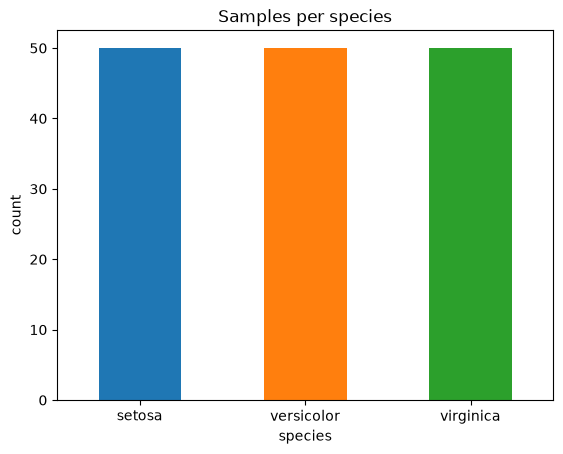

In [9]:
counts = df["species"].value_counts()
print(counts)

counts.reindex(class_names).plot(kind="bar", color=sns.color_palette()[:3], rot=0)
plt.title("Samples per species")
plt.ylabel("count")
plt.show()

**Balanced** (50 / 50 / 50). With balanced classes, plain accuracy is a fair score. With an imbalanced dataset (say 95% / 5%), accuracy would be misleading and we would need class weights or other metrics.

### 2.4 How the features separate the species

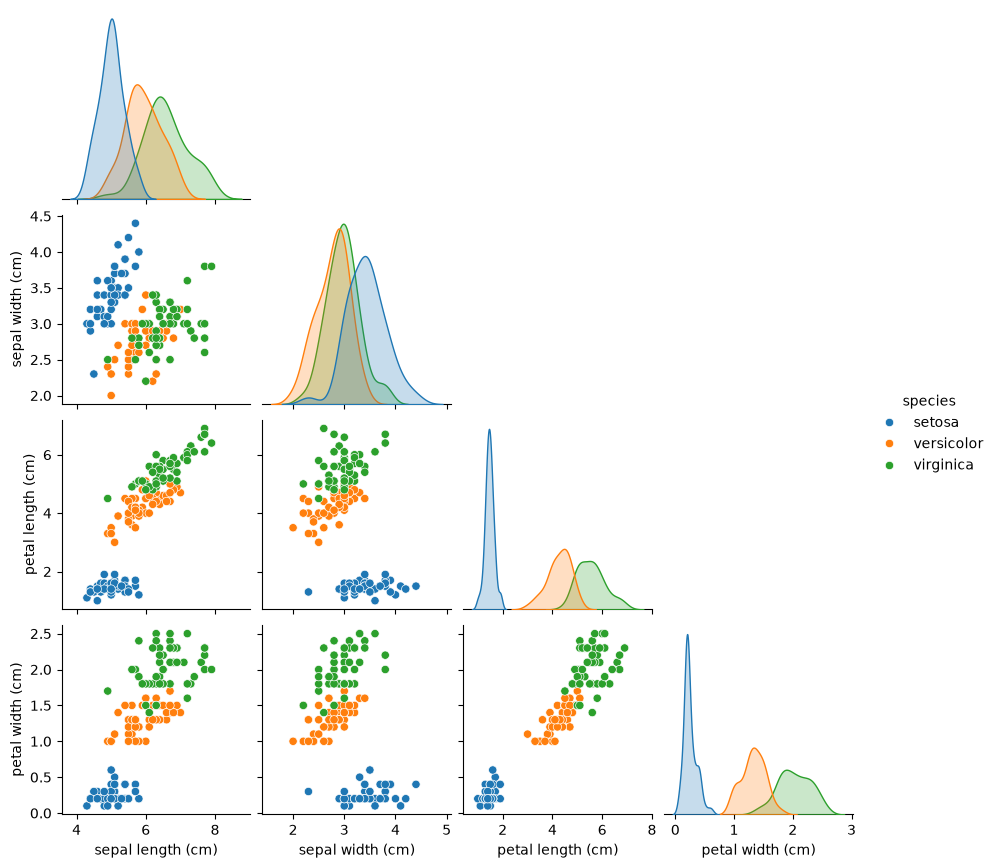

In [10]:
sns.pairplot(df.drop(columns=["target"]), hue="species", corner=True, height=2.2)
plt.show()

**What to notice:**
- **Setosa** (blue) is far from the other two in the petal measurements: it is easy to separate with a straight line.
- **Versicolor** and **virginica** overlap a little. This is where the network can make mistakes.
- The petal features separate the classes better than the sepal features.

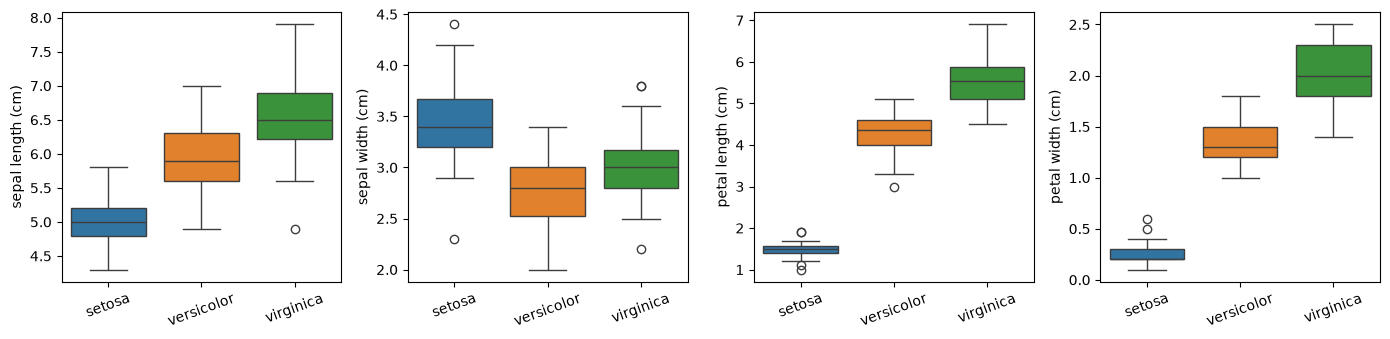

In [11]:
fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
for ax, col in zip(axes, iris.feature_names):
    sns.boxplot(data=df, x="species", y=col, hue="species", legend=False, ax=ax)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

Box plots also show **outliers** (single dots outside the whiskers). Iris has only a few mild ones, so we keep all rows.

## 3. Clean the data

Standard checklist. For each point we check, then decide.

In [12]:
print("Missing values per column:")
print(df.isna().sum())
print()
print("Total missing:", df.isna().sum().sum())

Missing values per column:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
species              0
dtype: int64

Total missing: 0


In [13]:
dups = df[df.duplicated(keep=False)]
print("Number of duplicated rows:", df.duplicated().sum())
dups

Number of duplicated rows: 1


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
101,5.8,2.7,5.1,1.9,2,virginica
142,5.8,2.7,5.1,1.9,2,virginica


**Findings and decisions**

| Check | Result | Decision |
|---|---|---|
| Missing values | none | nothing to fill or drop |
| Data types | all numeric (`float64`), target is an integer | nothing to convert |
| Duplicates | 1 duplicated pair (rows 101 and 142, same species) | **keep it**: two different flowers can have identical measurements, and removing it would make the classes uneven |
| Outliers | a few mild ones in the box plots | keep: they are real measurements, not errors |
| Class balance | 50 / 50 / 50 | no resampling needed |

> **If you did find missing values:** fill them with the mean or median of the *training* set (`SimpleImputer`) or drop the rows. If you found text columns, you would encode them (one-hot or label encoding) before the network.

## 4. Prepare the data

### 4.1 Separate features and labels

In [14]:
X = df[iris.feature_names].values.astype("float32")   # shape (150, 4)
y = df["target"].values                                # shape (150,), values 0, 1, 2

print("X shape:", X.shape)
print("y shape:", y.shape)
print("labels :", np.unique(y), "->", class_names)

X shape: (150, 4)
y shape: (150,)
labels : [0 1 2] -> ['setosa', 'versicolor', 'virginica']


### 4.2 Split into train / validation / test

We split **before** scaling, and we **stratify** so each part keeps the 1/3, 1/3, 1/3 class mix.

| Part | Size | Used for |
|---|---|---|
| Train | 60% (90 rows) | the network learns its weights from this |
| Validation | 20% (30 rows) | watch during training, to detect overfitting and tune choices |
| Test | 20% (30 rows) | touched **once** at the end, for the final honest score |

In [15]:
# first cut: 60% train, 40% temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.40, stratify=y, random_state=SEED)

# second cut: split the 40% half and half -> 20% validation, 20% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED)

print("train:", X_train.shape, " val:", X_val.shape, " test:", X_test.shape)
print("class counts in train:", np.bincount(y_train))
print("class counts in val  :", np.bincount(y_val))
print("class counts in test :", np.bincount(y_test))

train: (90, 4)  val: (30, 4)  test: (30, 4)
class counts in train: [30 30 30]
class counts in val  : [10 10 10]
class counts in test : [10 10 10]


### 4.3 Scale the features

We use **standardisation**: for every feature, `z = (x - mean) / std`. After this, each feature has mean about 0 and std about 1.

**Why:** gradient descent works much better when all inputs are on a similar scale. Otherwise the feature with big numbers dominates the weight updates and training is slower and less stable.

> **Important rule (avoids data leakage):** compute the mean and std from the **training set only** (`fit`), then apply the same numbers to validation and test (`transform`). If the scaler saw the test data, information from the test set would leak into training and the final score would be too optimistic.

In [16]:
scaler = StandardScaler()

X_train_s = scaler.fit_transform(X_train)   # learn mean/std from TRAIN, then scale it
X_val_s   = scaler.transform(X_val)         # reuse the same mean/std
X_test_s  = scaler.transform(X_test)        # reuse the same mean/std

print("Mean per feature in train after scaling:", X_train_s.mean(axis=0).round(3) + 0.0)
print("Std  per feature in train after scaling:", X_train_s.std(axis=0).round(3))

Mean per feature in train after scaling: [0. 0. 0. 0.]
Std  per feature in train after scaling: [1. 1. 1. 1.]


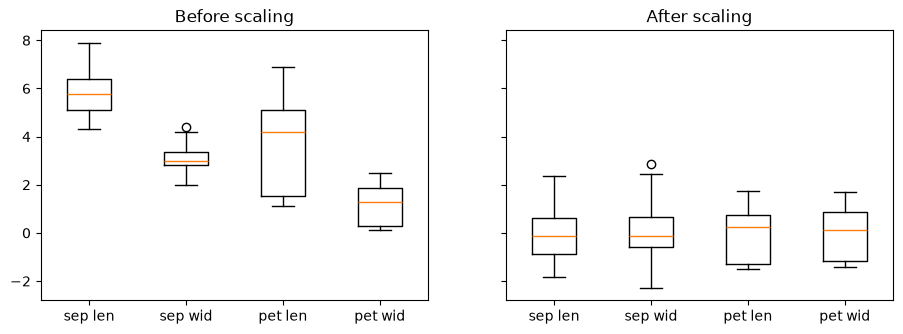

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5), sharey=True)
axes[0].boxplot(X_train, tick_labels=["sep len", "sep wid", "pet len", "pet wid"])
axes[0].set_title("Before scaling")
axes[1].boxplot(X_train_s, tick_labels=["sep len", "sep wid", "pet len", "pet wid"])
axes[1].set_title("After scaling")
plt.show()

### 4.4 The labels

The labels are integers `0, 1, 2`. We keep them as integers and use the loss `sparse_categorical_crossentropy`, which accepts integer labels directly.

> **Alternative:** one-hot encode the labels (`[1,0,0]`, `[0,1,0]`, `[0,0,1]`) and use `categorical_crossentropy`. It gives the same result. Use one-hot if you want the labels to match the shape of the softmax output.

## 5. Build the ANN

**Architecture:** `4 inputs -> Dense(16, relu) -> Dense(8, relu) -> Dense(3, softmax)`

| Layer | Nodes | Activation | Why |
|---|---|---|---|
| Input | 4 | none | one node per feature |
| Hidden 1 | 16 | ReLU | learns combinations of the features. ReLU is the default hidden activation: simple, fast, avoids vanishing gradients |
| Hidden 2 | 8 | ReLU | combines those into higher-level patterns |
| Output | 3 | **softmax** | one node per class. Softmax turns the 3 raw scores into probabilities that add up to 1 |

The number of hidden nodes (16, 8) is a choice, not a rule. Iris is easy, so a small network is enough.

**Count of parameters:** a `Dense` layer has `inputs x nodes` weights plus `nodes` biases.
- Hidden 1: `4 x 16 + 16 = 80`
- Hidden 2: `16 x 8 + 8 = 136`
- Output: `8 x 3 + 3 = 27`
- Total: `243`

In [18]:
model = keras.Sequential([
    keras.Input(shape=(4,)),                 # 4 features per flower
    layers.Dense(16, activation="relu"),     # hidden layer 1
    layers.Dense(8,  activation="relu"),     # hidden layer 2
    layers.Dense(3,  activation="softmax"),  # output: probability of each species
])

model.summary()

E0000 00:00:1791256203.236367   13587 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 243 (972.00 B)

 Trainable params: 243 (972.00 B)

 Non-trainable params: 0 (0.00 B)

### Compile: choose the loss, optimizer and metric

| Setting | Our choice | Meaning |
|---|---|---|
| **loss** | `sparse_categorical_crossentropy` | the error to minimise. For multi-class with integer labels. It punishes confident wrong answers heavily |
| **optimizer** | `adam` | the algorithm that updates the weights (a smarter version of gradient descent that adapts the step size). Learning rate 0.01 here |
| **metric** | `accuracy` | what we print to follow progress (fraction of correct predictions) |

**Which loss for which problem:**

| Problem | Output layer | Loss |
|---|---|---|
| Regression (a number) | 1 node, linear | `mse` |
| Binary classification | 1 node, sigmoid | `binary_crossentropy` |
| Multi-class (integer labels) | n nodes, softmax | `sparse_categorical_crossentropy` |
| Multi-class (one-hot labels) | n nodes, softmax | `categorical_crossentropy` |

In [19]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.01),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

## 6. Train

Key terms:

- **Epoch:** one full pass over the training data.
- **Batch size:** how many rows are used for one weight update. With 90 training rows and `batch_size=16`, one epoch has 6 updates.
- **Validation data:** after every epoch, the model is scored on the validation set (without learning from it). If the training loss keeps falling but the validation loss rises, the model is **overfitting** (memorising instead of learning).
- **EarlyStopping:** stops training when the validation loss stops improving for `patience` epochs, and (with `restore_best_weights=True`) goes back to the best weights. This protects against overfitting and saves time.

Behind the scenes, each update is exactly what you built from scratch: forward pass, loss, backpropagation, then `w = w - lr * dL/dw` (Adam adds some improvements to that last step).

In [20]:
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True,
)

history = model.fit(
    X_train_s, y_train,
    validation_data=(X_val_s, y_val),
    epochs=300,            # upper limit; early stopping will usually stop sooner
    batch_size=16,
    callbacks=[early_stop],
    verbose=0,
)

print("Stopped after", len(history.history["loss"]), "epochs")
print("Best validation loss:", round(min(history.history["val_loss"]), 4))

Stopped after 91 epochs
Best validation loss: 0.0519


### Learning curves

The most useful plot for diagnosing a network.

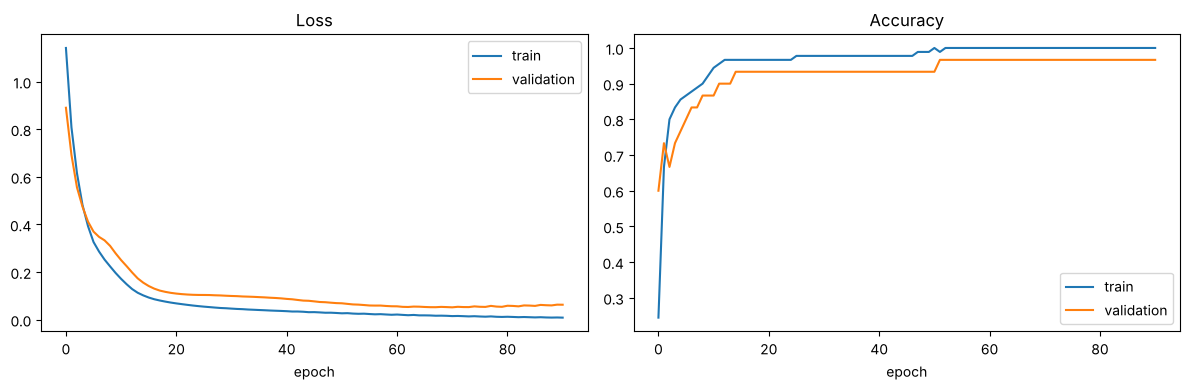

In [21]:
h = history.history
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(h["loss"], label="train")
axes[0].plot(h["val_loss"], label="validation")
axes[0].set_title("Loss")
axes[0].set_xlabel("epoch")
axes[0].legend()

axes[1].plot(h["accuracy"], label="train")
axes[1].plot(h["val_accuracy"], label="validation")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

**How to read the curves**

| What you see | Meaning | What to do |
|---|---|---|
| Both losses fall and stay close | healthy learning | nothing |
| Train loss falls, validation loss rises | **overfitting** | fewer nodes, dropout, early stopping, more data |
| Both losses stay high | **underfitting** | more nodes or layers, train longer, check the learning rate |
| Loss jumps around wildly | learning rate too high | lower the learning rate |

## 7. Evaluate on the test set

The test set was never used for training, scaling choices or early stopping, so this is the honest score.

> Look at the test set **once**. If you keep changing the model to improve the test score, the test set quietly becomes a second validation set and the score stops being honest.

In [22]:
test_loss, test_acc = model.evaluate(X_test_s, y_test, verbose=0)
print(f"Test loss    : {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

Test loss    : 0.1984
Test accuracy: 0.9333


### Predictions and the confusion matrix

The model outputs 3 probabilities per flower. `argmax` picks the class with the highest probability.

In [23]:
probs = model.predict(X_test_s, verbose=0)        # shape (30, 3), each row sums to 1
y_pred = np.argmax(probs, axis=1)                  # index of the largest probability

print("First 5 probability rows (setosa, versicolor, virginica):")
print(probs[:5].round(3))
print("Predicted classes:", y_pred[:5])
print("True classes     :", y_test[:5])

First 5 probability rows (setosa, versicolor, virginica):
[[0.    0.997 0.002]
 [1.    0.    0.   ]
 [0.003 0.99  0.008]
 [1.    0.    0.   ]
 [0.    0.001 0.999]]
Predicted classes: [1 0 1 0 2]
True classes     : [1 0 1 0 2]


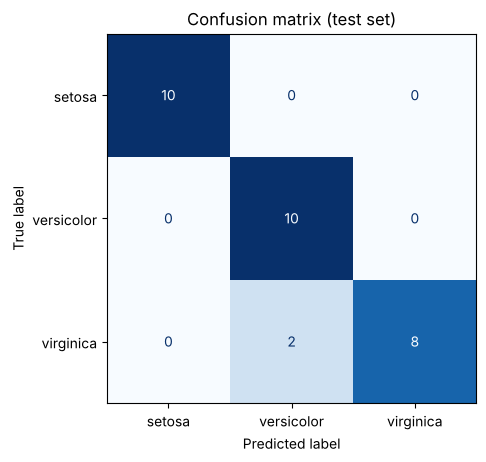

In [24]:
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(cmap="Blues", colorbar=False)
plt.title("Confusion matrix (test set)")
plt.show()

**Reading the confusion matrix:** rows are the **true** species and columns are the **predicted** species. Numbers on the diagonal are correct predictions. A number off the diagonal is a mistake (one species predicted as another).

In [25]:
print(classification_report(y_test, y_pred, target_names=class_names, digits=3))

              precision    recall  f1-score   support

      setosa      1.000     1.000     1.000        10
  versicolor      0.833     1.000     0.909        10
   virginica      1.000     0.800     0.889        10

    accuracy                          0.933        30
   macro avg      0.944     0.933     0.933        30
weighted avg      0.944     0.933     0.933        30



| Metric | Meaning |
|---|---|
| **precision** | of the flowers predicted as this species, how many really are |
| **recall** | of the flowers that really are this species, how many we found |
| **f1-score** | a balance of precision and recall |
| **support** | number of true samples of this species in the test set |

**Remember:** the test set has only 30 flowers, so one mistake changes the accuracy by about 3.3%. Do not read too much into small differences between runs. For a more reliable estimate on small data, use k-fold cross-validation.

## 8. Predict on a new flower

New data must go through the **same preprocessing** as the training data. The most common mistake is forgetting to scale it.

In [26]:
# sepal length, sepal width, petal length, petal width (in cm)
new_flower = np.array([[5.9, 3.0, 5.1, 1.8]], dtype="float32")

new_scaled = scaler.transform(new_flower)          # use the SAME scaler from training
p = model.predict(new_scaled, verbose=0)[0]

print("Probabilities:")
for name, prob in zip(class_names, p):
    print(f"  {name:<11} {prob:.3f}")
print("\nPredicted species:", class_names[int(np.argmax(p))])

Probabilities:
  setosa      0.000
  versicolor  0.105
  virginica   0.895

Predicted species: virginica


### Save the model and the scaler (to reuse later)

To use the model in another program you need **both** files: the model, and the scaler (otherwise you cannot scale new inputs the same way).

In [27]:
import joblib

model.save("iris_ann.keras")
joblib.dump(scaler, "iris_scaler.joblib")

# loading later:
# model  = keras.models.load_model("iris_ann.keras")
# scaler = joblib.load("iris_scaler.joblib")
print("saved: iris_ann.keras, iris_scaler.joblib")

saved: iris_ann.keras, iris_scaler.joblib


## 9. Cheat sheet

### Every choice we made, and why

| Step | Choice | Why |
|---|---|---|
| Problem type | multi-class classification | 3 classes, exactly one correct |
| Cleaning | none needed (kept 1 duplicate) | no missing values, all numeric |
| Split | 60 / 20 / 20, stratified | validation for tuning, test for the final score, same class mix in each |
| Scaling | `StandardScaler`, fit on train only | similar feature scales help gradient descent, no data leakage |
| Hidden layers | 16 and 8 nodes, ReLU | small network is enough, ReLU is the default |
| Output layer | 3 nodes, softmax | one probability per class |
| Loss | sparse categorical cross-entropy | multi-class with integer labels |
| Optimizer | Adam, lr = 0.01 | adaptive and works well by default |
| Regularisation | EarlyStopping on validation loss | stops before overfitting |
| Metric | accuracy (+ confusion matrix) | classes are balanced |

### Common mistakes

1. **Scaling before splitting** (or fitting the scaler on all the data): data leakage.
2. **Forgetting to scale new inputs** at prediction time.
3. **Wrong output layer / loss pair**, for example sigmoid with 3 classes, or softmax with `mse`.
4. **Judging the model on training accuracy.** Always use data the model did not train on.
5. **Tuning on the test set.** Tune on validation, test once.
6. **Not shuffling or stratifying** a split of ordered data. Iris is sorted by species, so an unshuffled split would put one species only in the test set.

### Things to try (one change at a time)

- Change the hidden layer sizes (`4`, `32`, `64`) and compare the validation curves.
- Remove the scaling and see how the training curves change.
- Lower or raise the learning rate (`0.001`, `0.1`).
- Add `layers.Dropout(0.2)` after a hidden layer.
- Use one-hot labels with `categorical_crossentropy` and check that the results match.
- Try a different seed (`SEED = 7`) to see how much the test accuracy moves on 30 samples.